In [38]:
# =====================导⼊依赖库=====================
import cv2
from skimage.util import random_noise
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

227 219 220


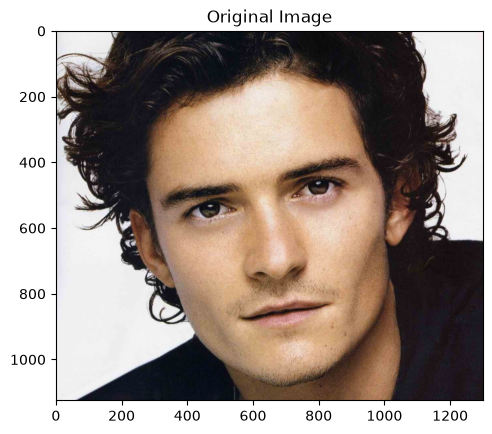

In [39]:
# ====================读取原始图像=====================
img_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_train.png")
save_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_original.jpg")
cvt_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_cvtrb.jpg")
gray_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_gray.jpg")
noise_comparison_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_noise_comparison.jpg")
filter_results_2x3_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_filter_results_2x3.jpg")
manual_median_path = Path(r"C:\Users\zaoan\Desktop\CVexp\image\exp2_manual_median.jpg")

img = cv2.imread(str(img_path))

# 获取图像中【100，100】这个像素的rbg三⾊
(b, g, r) = img[100, 100]

# 打印这个像素点的rbg参数
print(b, g, r)

# OpenCV 读入是 BGR，matplotlib 显示要转成 RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Original Image')
plt.savefig(str(save_path), dpi=300)
plt.show()

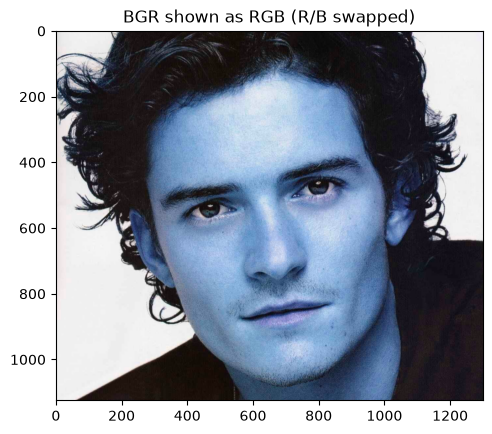

In [40]:
# 颜⾊空间转换，将原始图像BGR格式 转换成 RGB格式，蓝⾊和红⾊互换
# img 是 BGR，matplotlib 当 RGB 显示 → 红蓝对调
plt.imshow(img)
plt.title('BGR shown as RGB (R/B swapped)')
plt.savefig(str(cvt_path), dpi=300)
plt.show()

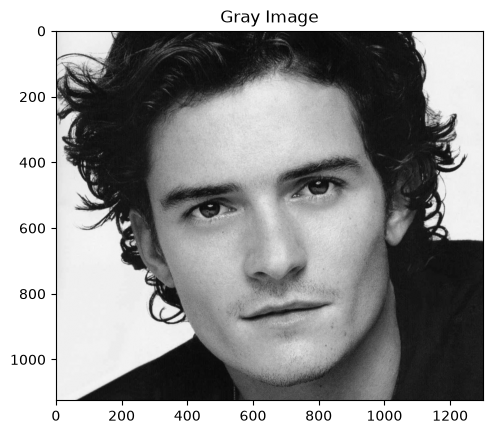

In [41]:
# 将原始图像的RBG格式转换为灰度图
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_img, cmap='gray')
plt.title('Gray Image')
plt.savefig(str(gray_path), dpi=300)
plt.show()

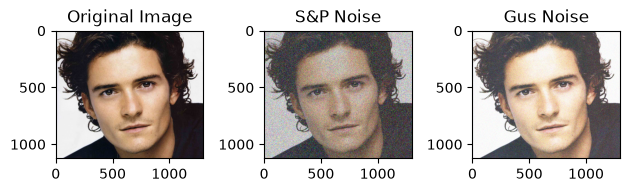

In [42]:
# ==========================添加噪声=========================
# mode='s&p'代表椒盐噪声，s代表⽩⾊，p代表⿊⾊，amount=0.4代表会有40%的像素
sp_noise_img = random_noise(img_rgb, mode='s&p', amount=0.4)
# mode='gaussian' 代表⾼斯噪声，会在每个像素上添加随机偏差，服从⾼斯分布（均值
gus_noise_img = random_noise(img_rgb, mode='gaussian', mean=0.2, var=0.03)
# 原图
plt.subplot(1, 3, 1)
plt.imshow(img_rgb, cmap='gray')
plt.title('Original Image')
# 椒盐噪声
plt.subplot(1, 3, 2)
plt.imshow(sp_noise_img, cmap='gray')
plt.title('S&P Noise')
# ⾼斯噪声
plt.subplot(1, 3, 3)
plt.imshow(gus_noise_img, cmap='gray')
plt.title('Gus Noise')
plt.tight_layout()
plt.savefig(str(noise_comparison_path), dpi=300)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.11982736866723577..1.0000000000000036].


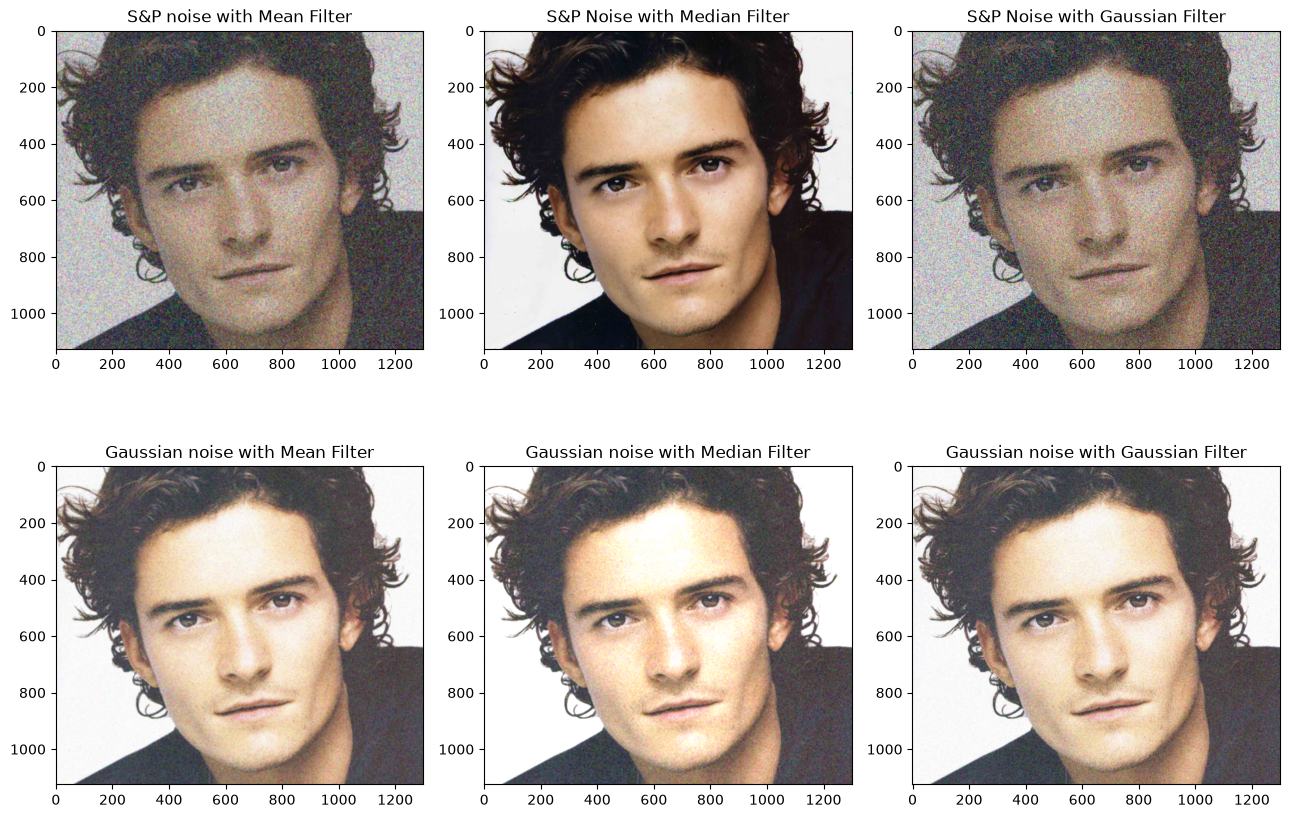

In [43]:
# =========================图像滤波=============================
# 均值滤波
mean_sp = cv2.blur(sp_noise_img, (5, 5))
mean_gus = cv2.blur(gus_noise_img, (5, 5))
# 中值滤波（需要 uint8）
mid_sp = cv2.medianBlur((sp_noise_img*255).astype(np.uint8), 5)
mid_gus = cv2.medianBlur((gus_noise_img*255).astype(np.uint8), 5)
# ⾼斯滤波
gauss_sp = cv2.GaussianBlur((sp_noise_img*255).astype(np.uint8), (5, 5), 0)
gauss_gus = cv2.GaussianBlur((gus_noise_img*255).astype(np.uint8), (5, 5), 0)
# 图像显⽰
plt.figure(figsize=(13, 9))
# 第1⾏：椒盐噪声
plt.subplot(2, 3, 1)
plt.imshow(mean_sp)
plt.title("S&P noise with Mean Filter")
plt.subplot(2, 3, 2)
plt.imshow(mid_sp)
plt.title("S&P Noise with Median Filter")
plt.subplot(2, 3, 3)
plt.imshow(gauss_sp)
plt.title("S&P Noise with Gaussian Filter")
# 第2⾏：⾼斯噪声
plt.subplot(2, 3, 4)
plt.imshow(mean_gus)
plt.title("Gaussian noise with Mean Filter")
plt.subplot(2, 3, 5)
plt.imshow(mid_gus)
plt.title("Gaussian noise with Median Filter")
plt.subplot(2, 3, 6)
plt.imshow(gauss_gus)
plt.title("Gaussian noise with Gaussian Filter")
plt.tight_layout()
plt.savefig(str(filter_results_2x3_path), dpi=300)
plt.show()

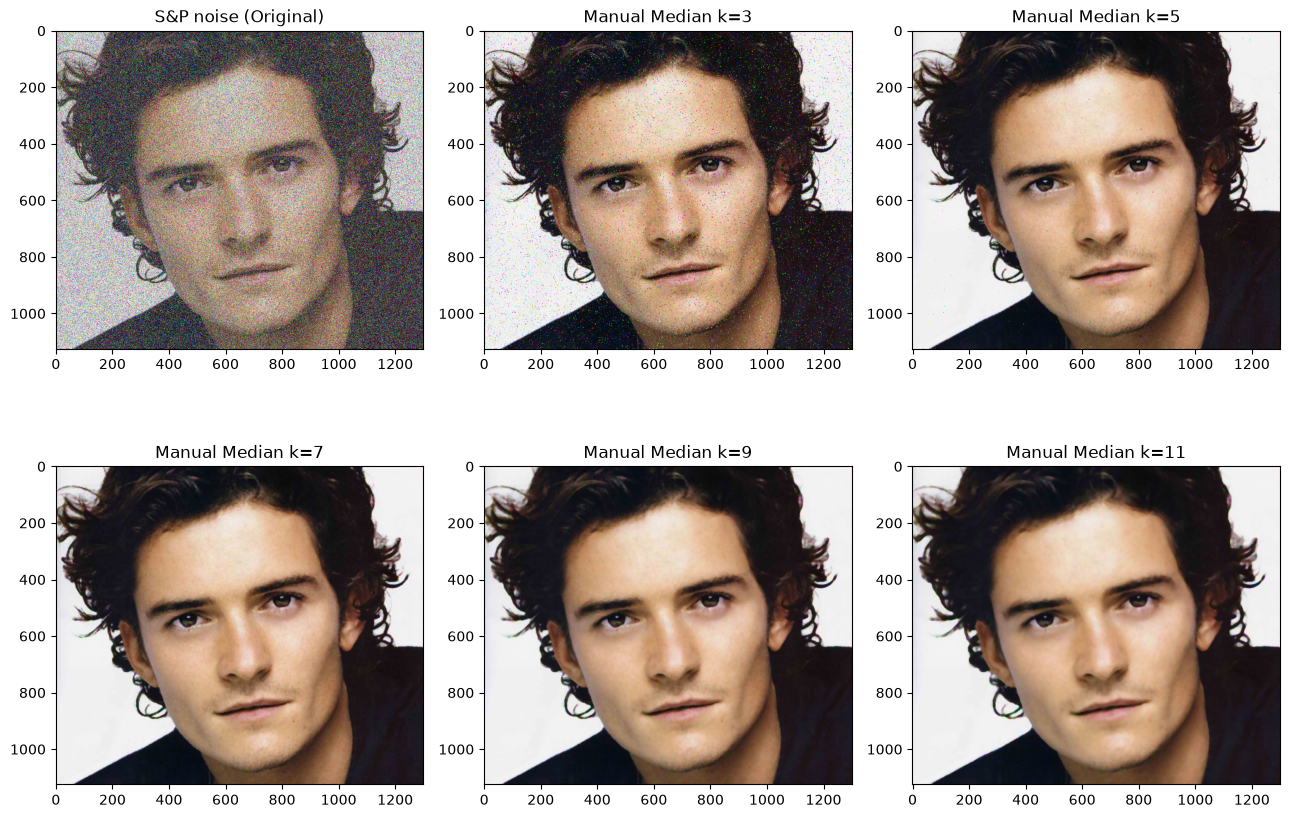

In [46]:
# ===========================⼿动实现中值滤波=========================
def manual_median_filter_color(image, kernel_size=5):
    """
    ⼿动实现彩⾊图像的中值滤波
    :param image: 输⼊彩⾊图像，numpy数组，shape=(H, W, 3)
    :param kernel_size: 滤波窗⼝⼤⼩
    :return: 中值滤波后的彩⾊图像
    """
    pad = kernel_size // 2
    # 对每个通道单独处理
    filtered_img = np.zeros_like(image)
    for c in range(3):  # 遍历通道 R,G,B
        channel = image[:, :, c]
        padded_channel = np.pad(channel, pad_width=pad, mode='edge')
        for i in range(channel.shape[0]):
            for j in range(channel.shape[1]):
                region = padded_channel[i:i + kernel_size, j:j + kernel_size]
                filtered_img[i, j, c] = np.median(region)
    return filtered_img


# 对之前添加椒盐噪声的图像进⾏⼿动中值滤波（不同 kernel size）
sp_uint8 = (sp_noise_img * 255).astype(np.uint8)
results = [manual_median_filter_color(sp_uint8, kernel_size=k) for k in [3, 5, 7, 9, 11]]

# 图像显示
plt.figure(figsize=(13, 9))
plt.subplot(2, 3, 1)
plt.imshow(sp_uint8)
plt.title("S&P noise (Original)")
plt.subplot(2, 3, 2)
plt.imshow(results[0])
plt.title("Manual Median k=3")
plt.subplot(2, 3, 3)
plt.imshow(results[1])
plt.title("Manual Median k=5")
plt.subplot(2, 3, 4)
plt.imshow(results[2])
plt.title("Manual Median k=7")
plt.subplot(2, 3, 5)
plt.imshow(results[3])
plt.title("Manual Median k=9")
plt.subplot(2, 3, 6)
plt.imshow(results[4])
plt.title("Manual Median k=11")
plt.tight_layout()
plt.savefig(str(manual_median_path), dpi=300)
plt.show()